<a href="https://colab.research.google.com/github/Adey-hub/DataX-Labs/blob/main/Task_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to SQLite database (create if not exists)
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

In [9]:
with open('sales_data.csv', 'wb') as f:
    f.write(data_files['sales_data.csv'])

# Load CSV into pandas
sd = pd.read_csv("sales_data.csv")

# Save to SQLite
sd.to_sql("sales", conn, if_exists="replace", index=False)

1000

In [10]:
query = """
SELECT Product_Category,
       SUM(Quantity_Sold) AS total_qty,
       SUM(Unit_Price * Quantity_Sold * (1 - Discount)) AS revenue
FROM sales
GROUP BY Product_Category
"""
sum_sd = pd.read_sql_query(query, conn)
print(sum_sd)

  Product_Category  total_qty       revenue
0         Clothing       6922  1.636084e+07
1      Electronics       6096  1.515323e+07
2             Food       5608  1.280833e+07
3        Furniture       6729  1.536378e+07


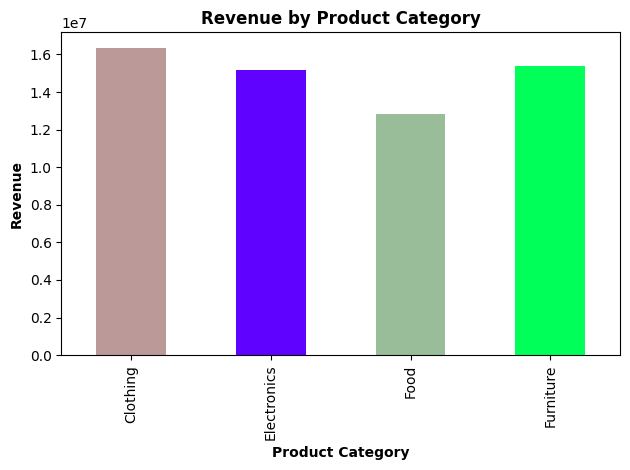

In [46]:
sum_sd.plot(kind='bar', x='Product_Category', y='revenue', legend=False, color=colors)
colors = ['#BB9999', '#6002FF', '#99BD99', '#00FF59']
plt.title("Revenue by Product Category", fontweight="bold")
plt.ylabel("Revenue", fontweight="bold")
plt.xlabel("Product Category", fontweight="bold")
plt.tight_layout()
plt.savefig("sales_chart.png")
plt.show()

In [43]:
query_region = """
SELECT Region,
       SUM(Unit_Price * Quantity_Sold * (1 - Discount)) AS revenue
FROM sales
GROUP BY Region
ORDER BY revenue DESC
"""
print(pd.read_sql_query(query_region, conn))

  Region       revenue
0  North  1.557034e+07
1   East  1.520228e+07
2   West  1.501889e+07
3  South  1.389466e+07


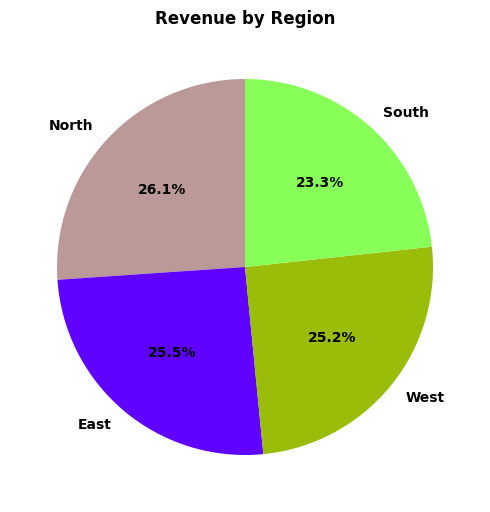

In [65]:
region_revenue_df = pd.read_sql_query(query_region, conn)

# Define colors before use
colors = ['#BB9999', '#6002FF', '#99BD08', '#88FF59']

# Set 'Region' as index for plotting
region_revenue_df_indexed = region_revenue_df.set_index('Region')

# Plotting the pie chart
region_revenue_df_indexed['revenue'].plot(kind='pie',
                                          figsize=(5,7), # Adjust figure size for better appearance
                                          autopct='%1.1f%%', # Show percentages
                                          startangle=90,
                                          colors=colors,
                                          legend=False,
                                          textprops={'fontweight': 'bold'}) # Make percentage labels bold

plt.title("Revenue by Region", fontweight="bold")
plt.ylabel("") # Remove default 'revenue' label from y-axis for pie chart
# plt.xlabel("Region", fontweight="bold") # xlabel is not appropriate for pie charts
plt.tight_layout()
plt.savefig("Revenue_chart.png")
plt.show()